<a href="https://colab.research.google.com/github/Alaaeldinaly/deep-learning-image-classification-assignment/blob/main/deep_learning_image_classification_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

plt.style.use("ggplot")
sns.set_style("whitegrid")

# 1) Import Libraries

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


# 2) Load Dataset

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# 3) Class Names

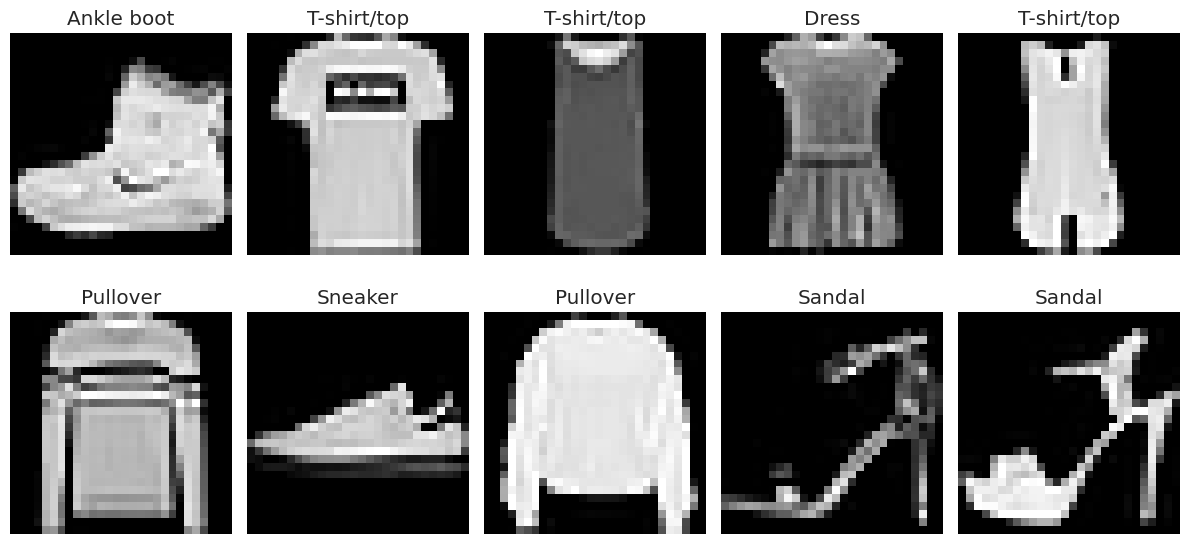

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4) Visualize Sample Images

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel values normalized.")
print("Min value:", X_train.min())
print("Max value:", X_train.max())

Pixel values normalized.
Min value: 0.0
Max value: 1.0


# 5) Normalize Pixel Values

**Explanation:**  
The image pixel values were scaled to the range 0 to 1 to improve neural network training stability.

In [6]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Encoded training labels shape:", y_train_cat.shape)
print("Encoded testing labels shape:", y_test_cat.shape)

Encoded training labels shape: (60000, 10)
Encoded testing labels shape: (10000, 10)


# 6) One-Hot Encode Labels

In [7]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# 7) Build a Simple Feedforward Neural Network

In [8]:
model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


# 8) Compile the Model

In [9]:
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7849 - loss: 0.6047 - val_accuracy: 0.8436 - val_loss: 0.4244
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8477 - loss: 0.4212 - val_accuracy: 0.8616 - val_loss: 0.3841
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8608 - loss: 0.3819 - val_accuracy: 0.8652 - val_loss: 0.3689
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8691 - loss: 0.3578 - val_accuracy: 0.8654 - val_loss: 0.3601
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8733 - loss: 0.3439 - val_accuracy: 0.8785 - val_loss: 0.3427
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8791 - loss: 0.3285 - val_accuracy: 0.8763 - val_loss: 0.3434
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8821 - loss: 0.3204 - val_accuracy: 0.8814 - val_loss: 0.3318
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8838 - loss: 0.3091 - val_accuracy: 0.

# 9) Train the Model

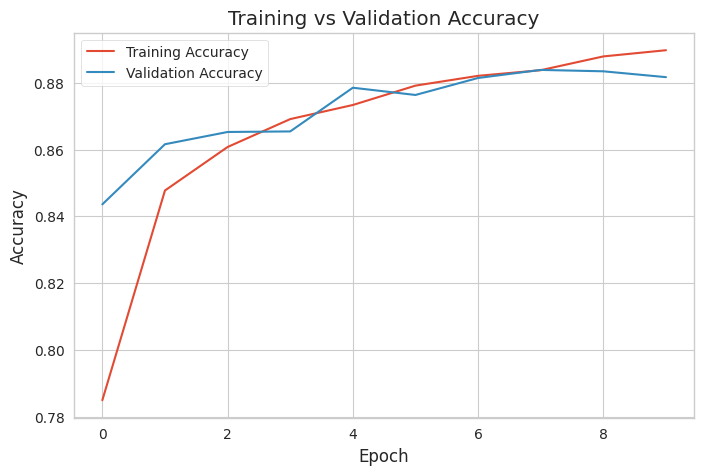

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 10) Plot Training and Validation Accuracy

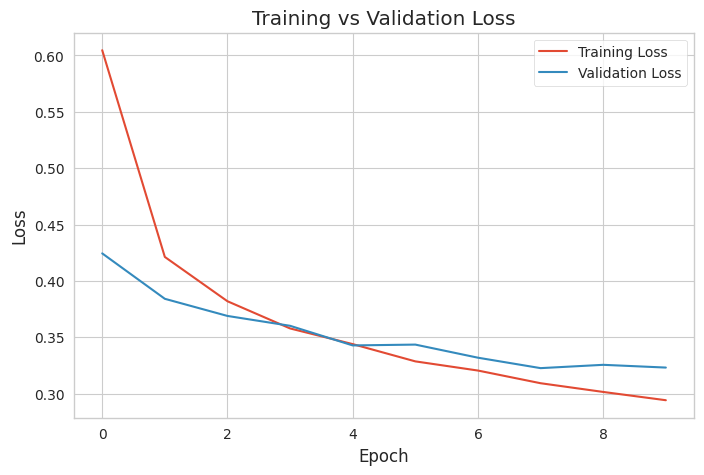

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 11) Plot Training and Validation Loss

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8744 - loss: 0.3519
Test Loss: 0.35189542174339294
Test Accuracy: 0.8744000196456909


# 12) Evaluate on Test Set

In [13]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("First 10 predicted labels:")
print(y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
First 10 predicted labels:
[9 2 1 1 6 1 4 6 5 7]


# 13) Predictions

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8744
Precision: 0.8742346139296624
Recall: 0.8744
F1-score: 0.8733335509325456


# 14) Performance Metrics

In [15]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.84      0.82      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.81      0.79      0.80      1000
       Dress       0.86      0.91      0.89      1000
        Coat       0.75      0.83      0.79      1000
      Sandal       0.99      0.94      0.96      1000
       Shirt       0.72      0.61      0.66      1000
     Sneaker       0.93      0.93      0.93      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.92      0.97      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



# 15) Classification Report

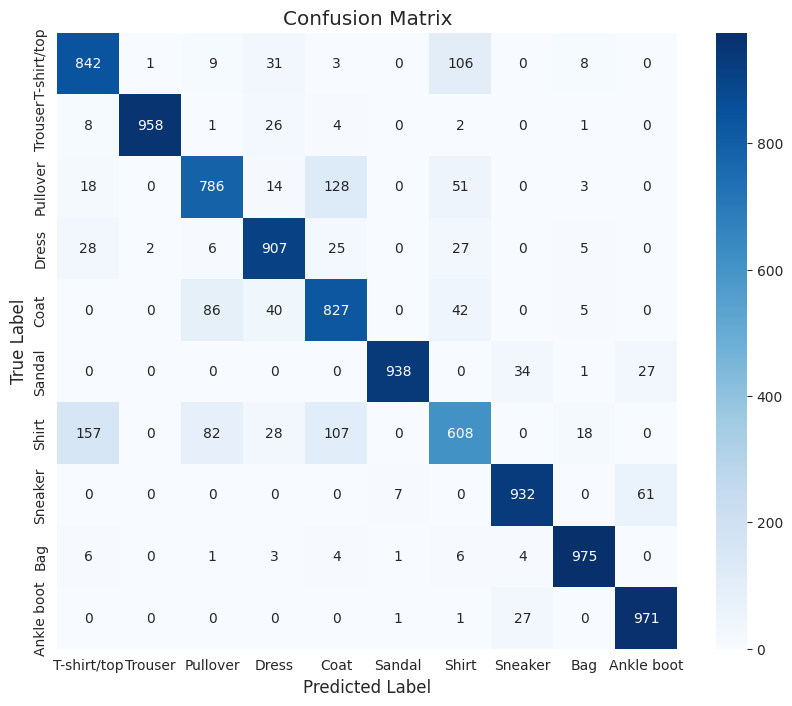

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# 16) Confusion Matrix

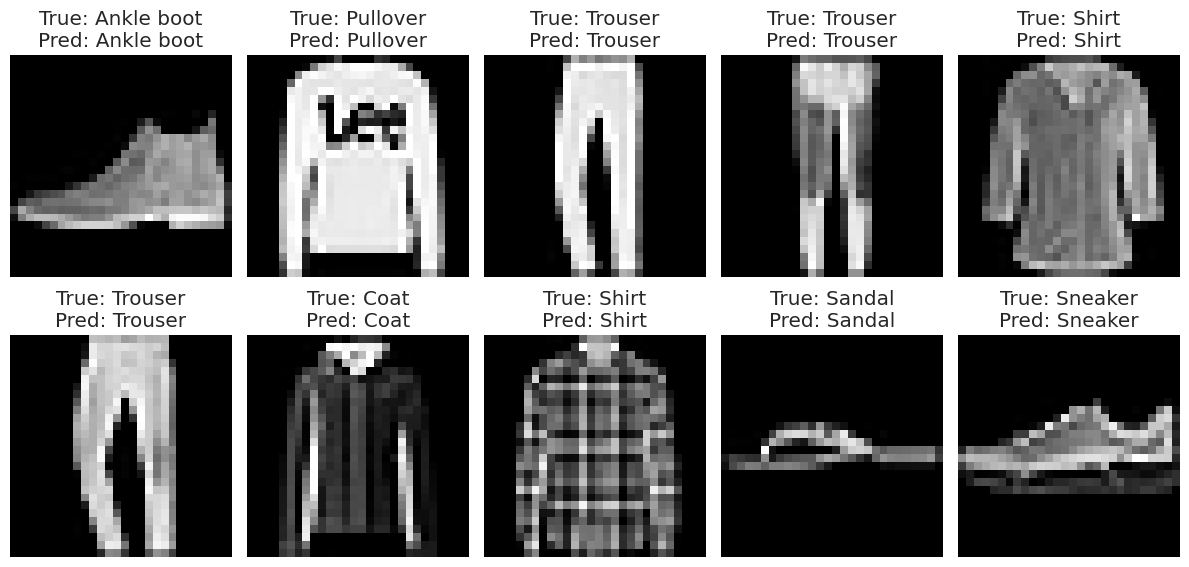

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap="gray")
    ax.set_title(f"True: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 17) Show Some Predictions

In [18]:
model2 = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

model2.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model2.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7832 - loss: 0.6044 - val_accuracy: 0.8407 - val_loss: 0.4456
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8419 - loss: 0.4356 - val_accuracy: 0.8574 - val_loss: 0.3893
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8555 - loss: 0.3954 - val_accuracy: 0.8536 - val_loss: 0.3910
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8617 - loss: 0.3759 - val_accuracy: 0.8726 - val_loss: 0.3525
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8686 - loss: 0.3563 - val_accuracy: 0.8818 - val_loss: 0.3388
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8759 - loss: 0.3385 - val_accuracy: 0.8820 - val_loss: 0.3291
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8784 - loss: 0.3299 - val_accuracy: 0.8793 - val_loss: 0.3286
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8801 - loss: 0.3242 - val_accuracy: 0.

# 18) Try a Larger Network

In [19]:
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test_cat)

y_pred_prob2 = model2.predict(X_test)
y_pred2 = np.argmax(y_pred_prob2, axis=1)

accuracy2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2, average="weighted")
recall2 = recall_score(y_test, y_pred2, average="weighted")
f12 = f1_score(y_test, y_pred2, average="weighted")

print("Improved Model Accuracy:", accuracy2)
print("Improved Model Precision:", precision2)
print("Improved Model Recall:", recall2)
print("Improved Model F1-score:", f12)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8797 - loss: 0.3357
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Improved Model Accuracy: 0.8797
Improved Model Precision: 0.8794264229565332
Improved Model Recall: 0.8797
Improved Model F1-score: 0.8781816566602209


# 19) Evaluate Improved Model

            Model  Accuracy  Precision  Recall  F1-score
0      Base Model    0.8744   0.874235  0.8744  0.873334
1  Improved Model    0.8797   0.879426  0.8797  0.878182


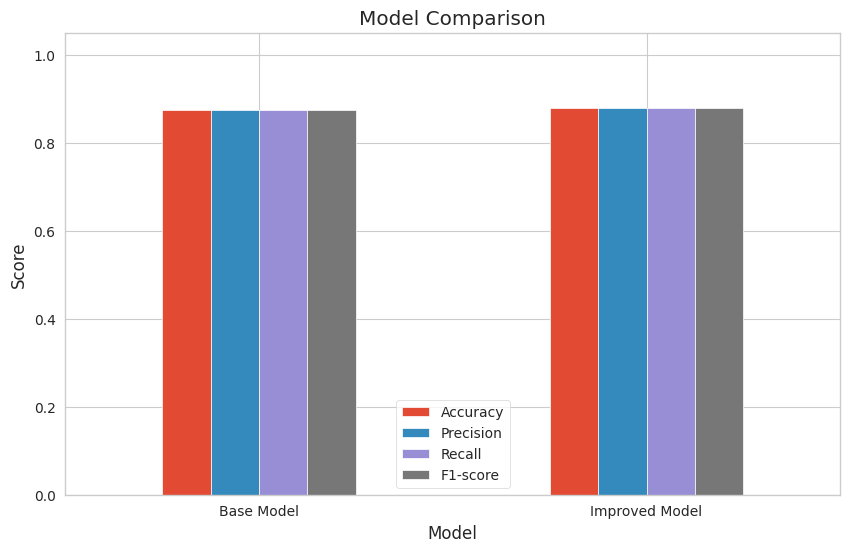

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["Base Model", "Improved Model"],
    "Accuracy": [accuracy, accuracy2],
    "Precision": [precision, precision2],
    "Recall": [recall, recall2],
    "F1-score": [f1, f12]
})

print(comparison_df)
comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

# 20) Compare Models

## Data Augmentation Optional

In [21]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

X_train_aug = X_train.reshape(-1, 28, 28, 1)
X_test_aug = X_test.reshape(-1, 28, 28, 1)

datagen.fit(X_train_aug)

# 21) Data Augmentation

In [22]:
aug_model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

aug_model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_aug = aug_model.fit(
    datagen.flow(X_train_aug, y_train_cat, batch_size=64),
    epochs=10,
    validation_data=(X_test_aug, y_test_cat)
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - accuracy: 0.6761 - loss: 0.8552 - val_accuracy: 0.7221 - val_loss: 0.6445
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7401 - loss: 0.6846 - val_accuracy: 0.7895 - val_loss: 0.5557
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.7586 - loss: 0.6372 - val_accuracy: 0.8063 - val_loss: 0.5119
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7684 - loss: 0.6124 - val_accuracy: 0.8168 - val_loss: 0.4932
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.7738 - loss: 0.5970 - val_accuracy: 0.8149 - val_loss: 0.4897
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.7808 - loss: 0.5806 - val_accuracy: 0.8230 - val_loss: 0.4623
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.7817 - loss: 0.5741 - val_accuracy: 0.8173 - val_loss: 0.4772
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.7865 - loss: 0.5609 - val_accurac

# 22) Train with Augmentation

In [23]:
aug_loss, aug_accuracy = aug_model.evaluate(X_test_aug, y_test_cat)

aug_pred_prob = aug_model.predict(X_test_aug)
aug_pred = np.argmax(aug_pred_prob, axis=1)

aug_precision = precision_score(y_test, aug_pred, average="weighted")
aug_recall = recall_score(y_test, aug_pred, average="weighted")
aug_f1 = f1_score(y_test, aug_pred, average="weighted")

print("Augmented Model Accuracy:", aug_accuracy)
print("Augmented Model Precision:", aug_precision)
print("Augmented Model Recall:", aug_recall)
print("Augmented Model F1-score:", aug_f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8181 - loss: 0.4685
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Augmented Model Accuracy: 0.8180999755859375
Augmented Model Precision: 0.8250996011290721
Augmented Model Recall: 0.8181
Augmented Model F1-score: 0.8180938341870219


# 23) Evaluate Augmented Model

             Model  Accuracy  Precision  Recall  F1-score
0       Base Model    0.8744   0.874235  0.8744  0.873334
1   Improved Model    0.8797   0.879426  0.8797  0.878182
2  Augmented Model    0.8181   0.825100  0.8181  0.818094


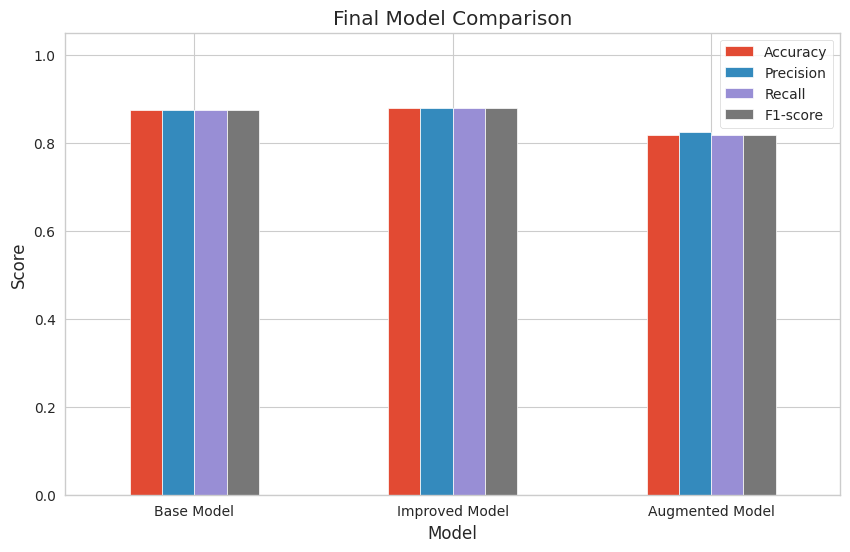

In [24]:
final_comparison = pd.DataFrame({
    "Model": ["Base Model", "Improved Model", "Augmented Model"],
    "Accuracy": [accuracy, accuracy2, aug_accuracy],
    "Precision": [precision, precision2, aug_precision],
    "Recall": [recall, recall2, aug_recall],
    "F1-score": [f1, f12, aug_f1]
})

print(final_comparison)
final_comparison.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()

# 24) Final Comparison

## Practical Application

# Practical Application and Deployment

A real-world application of this model could be in **fashion retail**.  
For example, an e-commerce platform could use the trained model to automatically classify uploaded clothing images into categories such as shirts, trousers, dresses, and shoes.

## Potential Deployment Challenges
- Handling large volumes of uploaded images
- Ensuring consistent image preprocessing
- Real-time prediction speed
- Integration with web or mobile platforms
- Model performance drift when new styles appear

## Monitoring Strategies
- Track prediction accuracy on new labeled samples
- Monitor class distribution in incoming images
- Log low-confidence predictions
- Retrain the model periodically with updated data

# 25) Markdown Cell for Deployment

# Conclusion

In this project, I built and evaluated a feedforward neural network for image classification using the Fashion MNIST dataset.

## Main steps completed:
- Loaded and visualized the dataset
- Normalized pixel values
- Encoded labels using one-hot encoding
- Built a feedforward neural network with ReLU and Softmax
- Trained and evaluated the model
- Compared model variations with different layer sizes
- Tested the impact of optional data augmentation
- Evaluated performance using accuracy, precision, recall, F1-score, confusion matrix, and classification report
- Discussed practical deployment and monitoring considerations

## Key insights:
- Neural networks can classify image data effectively even with a simple feedforward architecture
- Increasing layer size improved performance
- Data augmentation can improve robustness
- Fashion retail is a realistic deployment scenario for this type of image classification model